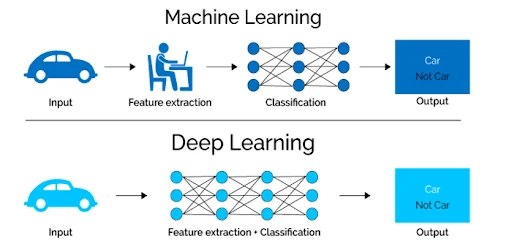

## 🔪 LSTM

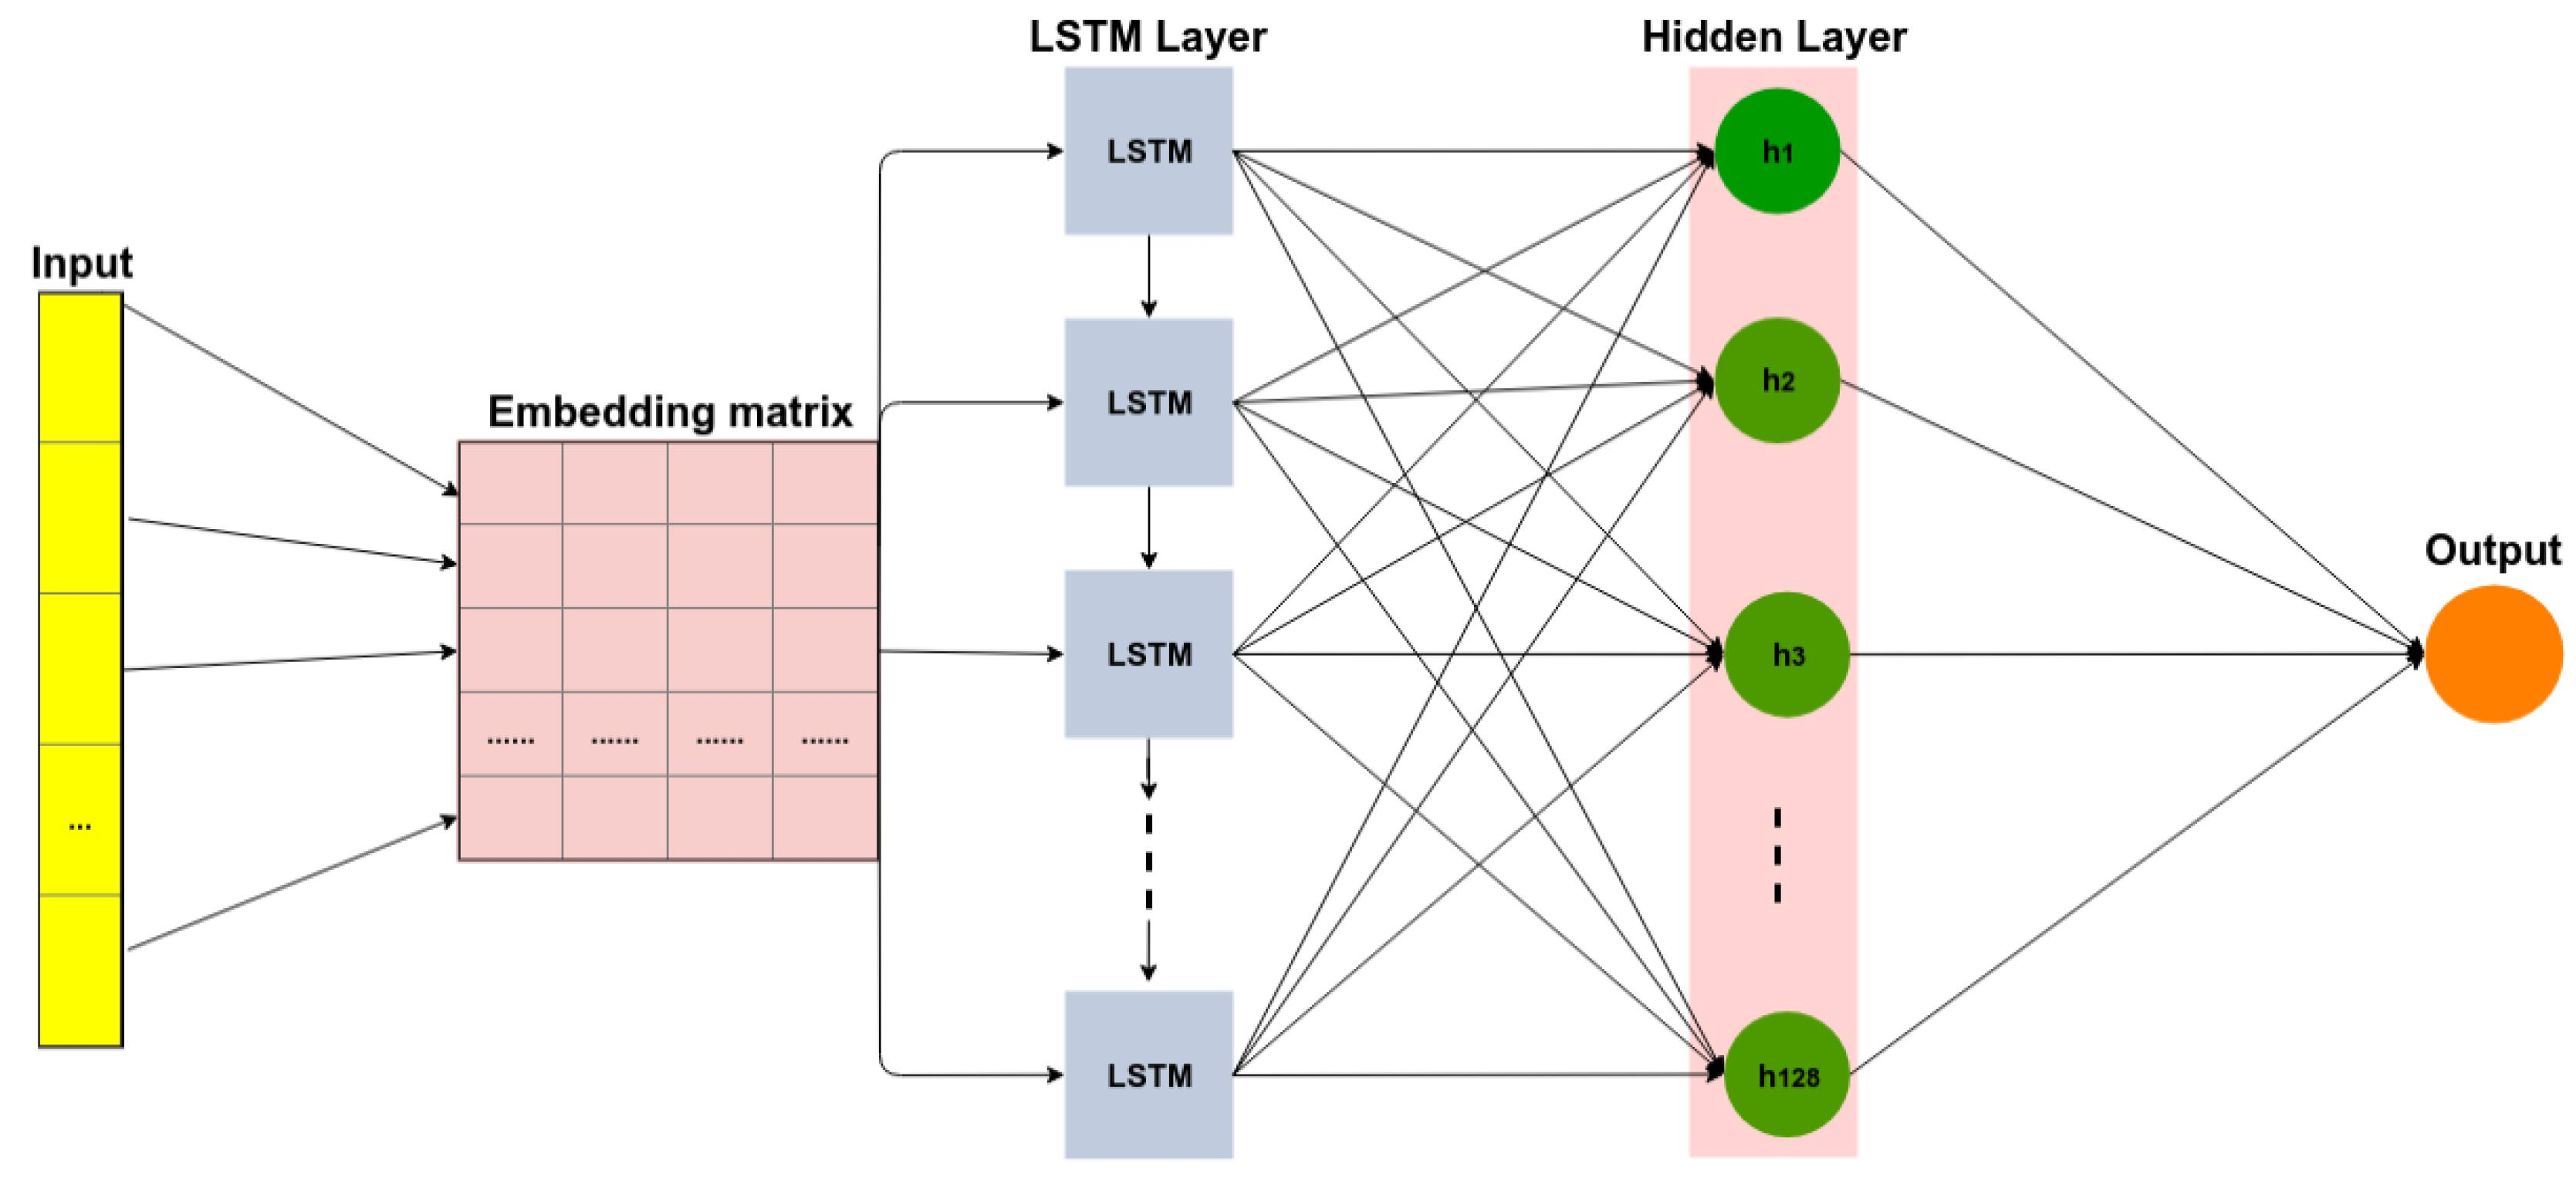

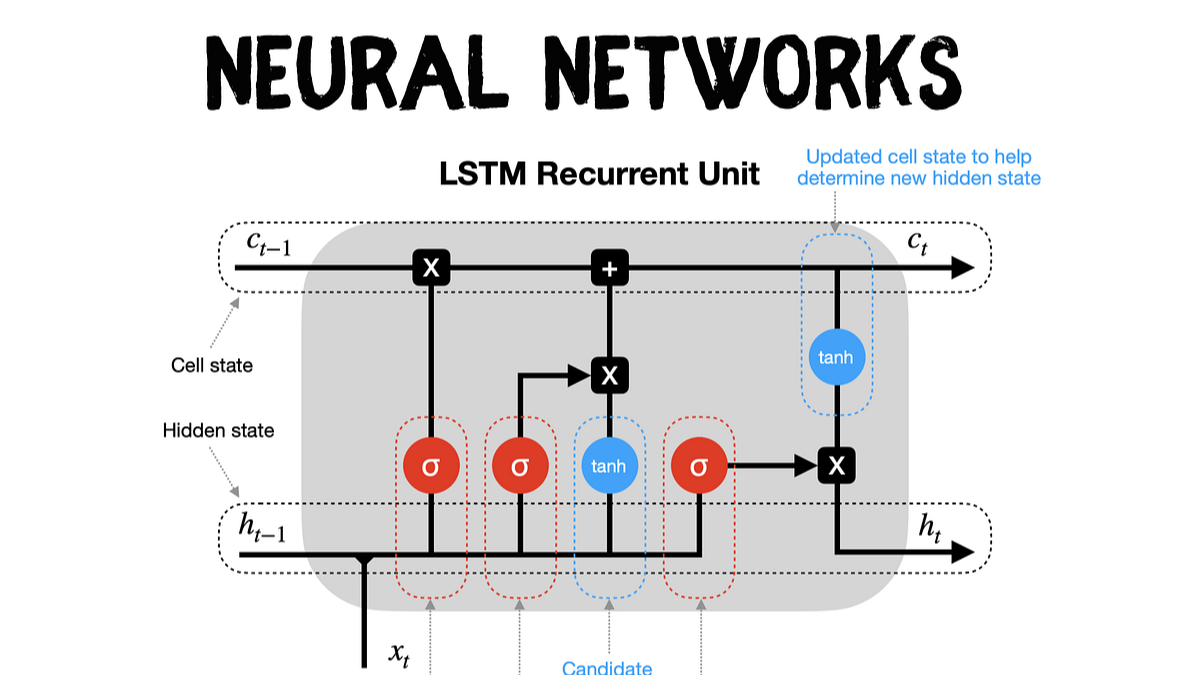

### 🎒 Packages

In [23]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.svm import LinearSVC
import wandb
import numpy as np
import re

from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import torch
from torch.nn import Module
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import stopwords

import torch.nn as nn

from sklearn.utils.class_weight import compute_class_weight
import copy

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### 🚙 Utilities

In [3]:
train_path = Path("..") / ".." / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / ".." / "data" / "test" / "train.tsv"

In [4]:
labels =["Ne", "S.Ne", "N", "S.Po", "Po"]

In [5]:
def draw_cm(y_true, y_pred, labels=labels):
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)

    cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # plt.figure(figsize=(10, 5))
    fig, axes = plt.subplots(figsize=(10, 5))

    cm.plot(
            cmap="Greens",
            ax=axes,
        )
    
    axes.set_xlabel("Predicted")
    axes.set_ylabel("Actual")

    plt.title("Confusion matrix")
    plt.show()
    

### 📊 Data

In [6]:
labels =["Ne", "S.Ne", "N", "S.Po", "Po"]

In [7]:
df = pd.read_csv(train_path, sep="\t")
df.head()

lstm = df.copy()

lstm.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [7]:
X, y = df["Phrase"], df["Sentiment"]

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

### 🧹 Simple Data cleaning

In [14]:
STOP_WORDS = set(stopwords.words("english"))

keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

# optional domain-specific words to REMOVE
# contextual_words = {"movie", "film"}

# final stopwords
STOP_WORDS = STOP_WORDS - keep_words


def cleaning(text):
    # lowercase
    text = text.lower()
    
    # remove parser's artifact
    text = re.sub(r"-lrb-|-rrb-", " ", text)
    
    # contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    
    # punctuation
    text = re.sub(r"[^a-z!? ]", " ", text)
    
    # split by <space>
    tokens = text.split()
    
    # stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS]
    
    # join
    text = " ".join(tokens)
    
    return text

In [12]:
clean_df = lstm.copy()

In [15]:
clean_df["Phrase"] = lstm["Phrase"].apply(lambda text: cleaning(text))

In [16]:
clean_df = clean_df[clean_df["Phrase"] != ""]

In [99]:
X = clean_df["Phrase"]
y = clean_df["Sentiment"]

In [100]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

### 🌋 Build the vocabulary (Assign word with index)

#### 🎮 Build the vocabulary from train set

In [ ]:
############################################### DATA CLEANING
STOP_WORDS = set(stopwords.words("english"))

keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

# optional domain-specific words to REMOVE
# contextual_words = {"movie", "film"}

# final stopwords
STOP_WORDS = STOP_WORDS - keep_words


def cleaning(text):
    # lowercase
    text = text.lower()
    
    # remove parser's artifact
    text = re.sub(r"-lrb-|-rrb-", " ", text)
    
    # contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    
    # punctuation
    text = re.sub(r"[^a-z!? ]", " ", text)
    
    # split by <space>
    tokens = text.split()
    
    # stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS]
    
    # join
    text = " ".join(tokens)
    
    return text

# Apply clean for both train/val
clean_df["Phrase"] = lstm["Phrase"].apply(lambda text: cleaning(text))
clean_df = clean_df[clean_df["Phrase"] != ""]

X = clean_df["Phrase"]
y = clean_df["Sentiment"]
############################################### TRAIN/VAL SPLITING
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
############################################### BUILD VOCAB AND DATASEt/DATALOADER
# input the series of text
def build_vocab(texts : pd.Series, max_size=20000):
    counter = Counter()
    
    for text in texts:
        words = text.split()
        counter.update(words)
    
    most_common = counter.most_common(max_size)
    
    vocab = {word: i+2 for i, (word, _) in enumerate(most_common)}
    
    # vocabulary index for <PAD> and <UNK>
    # for padding the sentence when len(seq) < seq_size
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    
    return vocab

vocab = build_vocab(X_train)

# Map sentence to sequence of ID
def encode(text : str, vocab):
    # if word is unknown then <UNK>
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

# Encode sentence -> Sequence of IDs
X_train_seq = [encode(text, vocab) for text in X_train]

# Use the vocabulary learned from the train set
X_val_seq = [encode(text, vocab) for text in X_val]

# Padding
MAX_LEN = 31

def pad(seq : list[int], max_len=MAX_LEN):
    # less than max_len -> pad pad
    if len(seq) < max_len:
        # 0 is the index of <PAD>
        seq = seq + [0]*(max_len - len(seq))
    else:
    # greater than max_len -> get up to max_len
        seq = seq[:max_len]
        
    # return the seq of index of MAX_LEN
    return seq

# (train_size, MAX_LEN)
X_train_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_train_seq] )

# (val_size, MAX_LEN)
X_val_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_val_seq] )

y_train = torch.tensor(y_train.values)
y_val = torch.tensor(y_val.values)

## Ddataset and DataLoader
class TextDataset(Dataset):
    def __init__(self, X, y):
        # tensor X and y
        # X shape (train_size, seq_size)
        # ID ID ID ID
        # ID ID ID ID
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [102]:
vocab = build_vocab(X_train)

In [103]:
vocab["<PAD>"]

0

### 🈂️ Map sentence -> sequence of tokens (id)

In [104]:
def encode(text : str, vocab):
    # if word is unknown then <UNK>
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

- Encode a sentence into a list of index
- "I will kill you"
- [32, 12, 34, 54]

##### 🛢️ Convert each sentence into a list of IDs

In [105]:
X_train_seq = [encode(text, vocab) for text in X_train]

# Use the vocabulary learned from the train set
X_val_seq = [encode(text, vocab) for text in X_val]

In [106]:
max([len(s) for s in X_train_seq])

31

Now each of the sentence/phrase is a list of word INDEX

In [107]:
X_train_seq[3]

[6497, 89, 314, 6138, 458, 78, 40]

#### 🧣 Padding sequence of numbers, if the current sequence is less than MAX_LEN
- We need a fixed-size sequence len, then we need to pad
- Or remove the size of the sequence to the length

In [108]:
MAX_LEN = 31

def pad(seq : list[int], max_len=MAX_LEN):
    # less than max_len -> pad pad
    if len(seq) < max_len:
        # 0 is the index of <PAD>
        seq = seq + [0]*(max_len - len(seq))
    else:
    # greater than max_len -> get up to max_len
        seq = seq[:max_len]
        
    # return the seq of index of MAX_LEN
    return seq

#### 🔳 For every sequence in the train/val, padding and convert the set into tensor

In [ ]:
MAX_LEN = 31

# (train_size, MAX_LEN)
X_train_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_train_seq] )

# (val_size, MAX_LEN)
X_val_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_val_seq] )

y_train = torch.tensor(y_train.values)
y_val = torch.tensor(y_val.values)

#### 🤿 DIM and SHAPE

In [110]:
X_train_pad.dim()

2

In [111]:
X_train_pad.shape

torch.Size([139379, 31])

In [112]:
y_train.dim()

1

In [113]:
y_train.shape

torch.Size([139379])

### 🏐 Creating the `dataset` and `dataloader` for tensor data storage

In [114]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        # tensor X and y
        # X shape (train_size, seq_size)
        # ID ID ID ID
        # ID ID ID ID
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### 🐡 Design the model architecture

#### 👿 Important notes

✅ Embedding produces the features used by LSTM

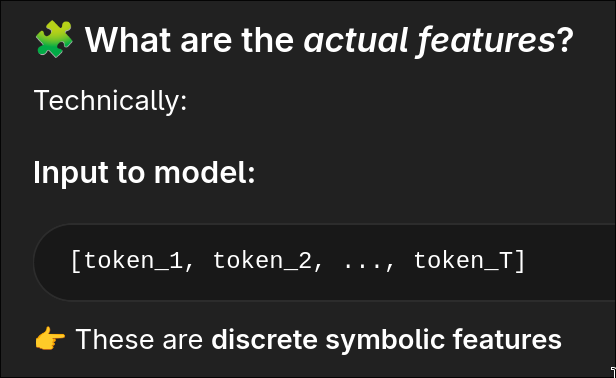

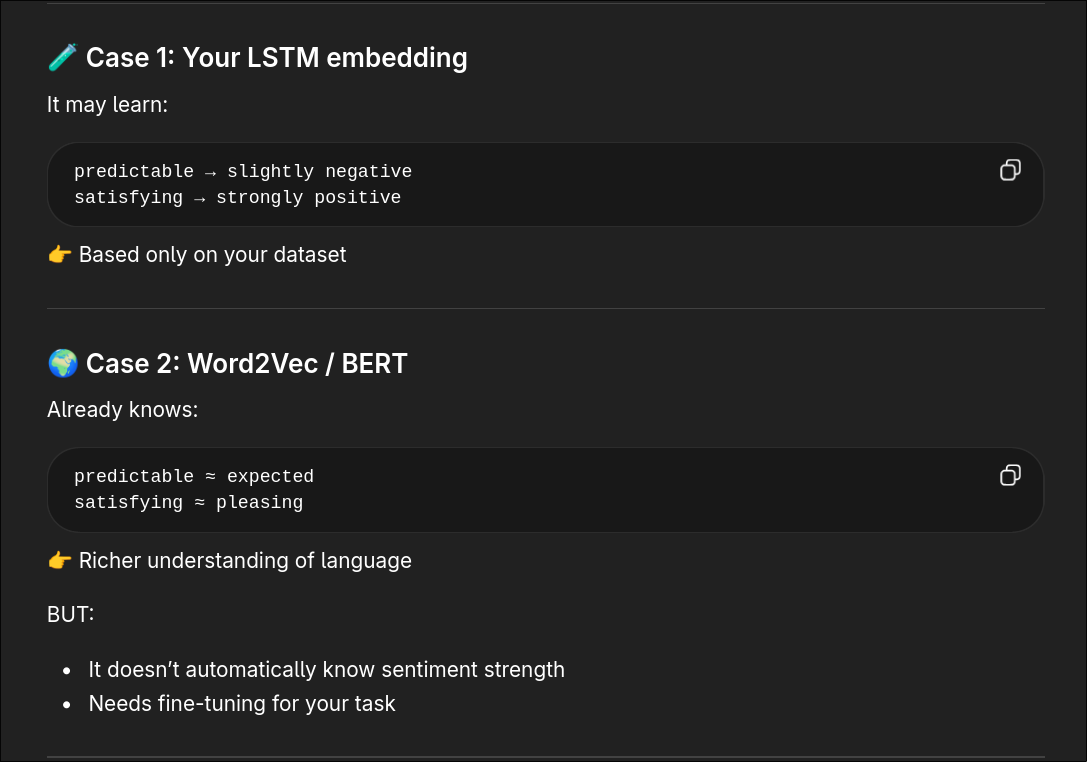

#### ⚕️ Embeddings = 
- 🎯 “What helps sentiment classification?”, 
- 🎯 “What representation of words makes this task easiest?”

In [8]:
# model = nn.Sequential(
#     nn.Embedding(vocab_size, embedding_dim),
#     nn.LSTM(embedding_dim, hidden_dim),
#     nn.Linear(hidden_dim, num_classes)
# )

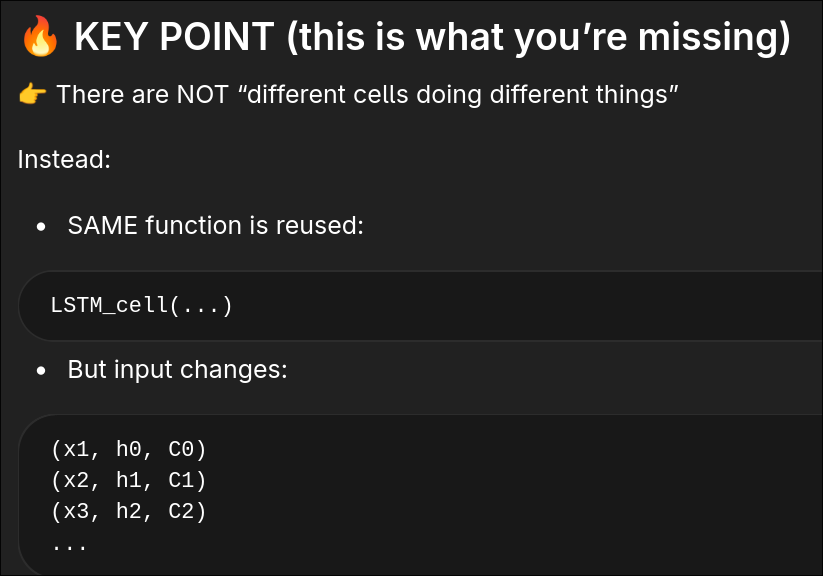

In [86]:
class M1(nn.Module):
    def __init__(
            self, 
            vocab_size, 
            embed_dim, 
            hidden_dim, 
            num_classes
        ):
        super().__init__()
        
        # input is a tensor of padding [ID, ID, ID, ID, ID]
        
        # embedding layer
        # a simple look up for embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        
        # lstm layer
        # each time step, each token -> embedding_dim
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            # hidden_dim,
            batch_first=True,
            num_layers=1,
            # device=device
        )
        
        # self.dropout = nn.Dropout(0.3)
        
        # dense layer
        self.fc = nn.Linear(
            in_features=hidden_dim, 
            out_features=num_classes
        )
    
    def forward(self, x):
        # x: (batch_size, seq_len)

        embedded = self.embedding(x)
        # (batch_size, seq_len, embed_dim)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Take the last hidden state
        last_hidden = hidden[-1]
        # (batch_size, hidden_dim)

        # out = self.dropout(last_hidden)
        out = self.fc(last_hidden)

        return out

#### 🇦🇨 Train loop without early stopping

In [85]:
#################################################################### - Traning step [Preprocessing - feature engineering]
def train_model(
        model, 
        train_loader, 
        val_loader, 
        optimizer, 
        criterion, 
        epochs
    ):
    
    # mini-batch gradient descent
    for epoch in range(epochs):
        print(f"🤩 Epoch {epoch + 1} started")
        # set to train mode
        model.train()
        total_loss = 0
        
        print(f"💿 ##### Train starts")
        for X_batch, y_batch in train_loader:
            # Move data to GPU
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Set zero gradient
            optimizer.zero_grad()
            
            # compute the values
            outputs = model(X_batch)
            # calculate loss from criterion
            loss = criterion(outputs, y_batch)
            
            # calcualte the gradients for parameters
            loss.backward()
            # Update the parameters
            optimizer.step()
            optimizer.zero_grad()
            
            # loss on this batch
            total_loss += loss.item()
        
        # loss on a batch, not full dataset
        avg_train_loss = total_loss / len(train_loader)
        
        print(f"💿 ##### Evaluation starts")
        model.eval()
        val_loss = 0
        preds, labels = [], []
        
        # set no gradient
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                # move data to device
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                # calculate output
                outputs = model(X_batch)
                # loss on a batch
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()
                
                # get the max value
                pred = outputs.argmax(dim=1)
                
                # move preds back to cpu
                preds.extend(pred.cpu().numpy())
                labels.extend(y_batch.cpu().numpy())
        
        # Average loss on a batch
        avg_val_loss = val_loss / len(val_loader)
        
        
        acc = accuracy_score(labels, preds)
        f1_macro = f1_score(labels, preds, average="macro")
        f1_weighted = f1_score(labels, preds, average="weighted")
        
        wandb.log({
            "epoch": epoch + 1,
            # on a batch
            "train_loss": avg_train_loss,
            # on a batch
            "val_loss": avg_val_loss,
            # metrics
            "val_accuracy": acc,
            "val_f1_macro": f1_macro,
            "val_f1_weighted": f1_weighted
        })
        
        print(f"🍖 ##### Metrics")
        
        
        print(f"""🍖 ######### Train Loss: {avg_train_loss:.4f}
🍖 ######### Val Loss: {avg_val_loss:.4f}
🍖 ######### Val Acc: {acc:.4f}
🍖 ######### Val F1 Macro: {f1_macro:.4f}
🍖 ######### Val F1 Weighted: {f1_weighted:.4f}

""")  
#################################################################### - End

#### 👇 Train loop with early stopping

In [16]:
def train_model_v1(
        model, 
        train_loader, 
        val_loader, 
        optimizer, 
        criterion, 
        epochs,
        # number of times that
        # train_loss decreases
        # val_loss increases
        patience=3,
        min_delta=1e-4
    ):
    
    best_val_loss = float("inf")
    patience_counter = 0
    
    for epoch in range(epochs):
        print(f"🤩 Epoch {epoch + 1} started")
        
        # TRAIN 
        model.train()
        total_loss = 0
        
        print(f"💿 ##### Train starts")
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # VALIDATION 
        print(f"💿 ##### Evaluation starts")
        model.eval()
        
        val_loss = 0
        preds, labels = [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()
                
                pred = outputs.argmax(dim=1)
                preds.extend(pred.cpu().numpy())
                labels.extend(y_batch.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        
        acc = accuracy_score(labels, preds)
        f1_macro = f1_score(labels, preds, average="macro")
        f1_weighted = f1_score(labels, preds, average="weighted")
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": acc,
            "val_f1_macro": f1_macro,
            "val_f1_weighted": f1_weighted
        })
        
        print(f"""🍖 ######### Train Loss: {avg_train_loss:.4f}
🍖 ######### Val Loss: {avg_val_loss:.4f}
🍖 ######### Val Acc: {acc:.4f}
🍖 ######### Val F1 Macro: {f1_macro:.4f}
🍖 ######### Val F1 Weighted: {f1_weighted:.4f}""")
        
        # EARLY STOPPING 
        # BEST IS FROM THE PREVIOUS
        # After one epoch
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            patience_counter = 0
            
            # Save best model
            torch.save(model.state_dict(), "best_model.pt")
            print("✅✅✅✅✅✅ Validation improved — model saved")
            print("")
        
        else:
            patience_counter += 1
            print(f"⏳⏳⏳⏳⏳ No improvement ({patience_counter}/{patience})")
            
            # We can't be patient anymore
            # val has increased
            if patience_counter >= patience:
                print("❌❌❌❌❌ Early stopping triggered")
                break

#### 🖲️ v1.0.0 Model training, normal train, no tuning

In [87]:
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 5,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 30,
}

wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v1.0.0",
    config=config,
)

# train/val dataset
train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)

# Load the tensor from the dataset X_train, y_train
# (batch_size, seq_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Create the model
model = M1(
    vocab_size=config["vocab_size"],
    embed_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    num_classes=config["num_classes"],
)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config["learning_rate"]
    )



train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=config["epochs"]
)

epoch,▁▃▅▆█
train_loss,█▂▂▂▁
val_accuracy,▁▁▁▁▁
val_f1_macro,▁▁▁▁▁
val_f1_weighted,▁▁▁▁▁
val_loss,▅▅█▁▃
epoch,5
train_loss,1.28854
val_accuracy,0.50668
val_f1_macro,0.13452
val_f1_weighted,0.34079


🤩 Epoch 1 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ##### Metrics
🍖 ######### Train Loss: 1.1604
🍖 ######### Val Loss: 1.0689
🍖 ######### Val Acc: 0.5698
🍖 ######### Val F1 Macro: 0.3375
🍖 ######### Val F1 Weighted: 0.5246


🤩 Epoch 2 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ##### Metrics
🍖 ######### Train Loss: 0.9994
🍖 ######### Val Loss: 0.9468
🍖 ######### Val Acc: 0.6206
🍖 ######### Val F1 Macro: 0.4717
🍖 ######### Val F1 Weighted: 0.6060


🤩 Epoch 3 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ##### Metrics
🍖 ######### Train Loss: 0.8468
🍖 ######### Val Loss: 0.8608
🍖 ######### Val Acc: 0.6497
🍖 ######### Val F1 Macro: 0.5130
🍖 ######### Val F1 Weighted: 0.6336


🤩 Epoch 4 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ##### Metrics
🍖 ######### Train Loss: 0.7633
🍖 ######### Val Loss: 0.8389
🍖 ######### Val Acc: 0.6610
🍖 ######### Val F1 Macro: 0.5398
🍖 ######### Val F1 Weighted: 0.6543


🤩 Epoch 5 started
💿 ##### Train starts
💿

In [90]:
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 30,
}

wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v1.0.1",
    config=config,
)

# train/val dataset
train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)

# Load the tensor from the dataset X_train, y_train
# (batch_size, seq_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Create the model
model = M1(
    vocab_size=config["vocab_size"],
    embed_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    num_classes=config["num_classes"],
)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config["learning_rate"]
    )



train_model_v1(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=config["epochs"]
)

🤩 Epoch 1 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.1528
🍖 ######### Val Loss: 1.0571
🍖 ######### Val Acc: 0.5734
🍖 ######### Val F1 Macro: 0.3485
🍖 ######### Val F1 Weighted: 0.5286

✅✅✅✅✅✅ Validation improved — model saved
🤩 Epoch 2 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.0159
🍖 ######### Val Loss: 1.0126
🍖 ######### Val Acc: 0.5913
🍖 ######### Val F1 Macro: 0.3762
🍖 ######### Val F1 Weighted: 0.5647

✅✅✅✅✅✅ Validation improved — model saved
🤩 Epoch 3 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 0.8950
🍖 ######### Val Loss: 0.8996
🍖 ######### Val Acc: 0.6407
🍖 ######### Val F1 Macro: 0.4833
🍖 ######### Val F1 Weighted: 0.6245

✅✅✅✅✅✅ Validation improved — model saved
🤩 Epoch 4 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 0.7946
🍖 ######### Val Loss: 0.8539
🍖 ######### Val Acc: 0.6504
🍖 ######### Val F1 Macro: 0.5182
🍖 ######### Val F1 Wei

In [115]:
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 31,
}

wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v1.0.2",
    config=config,
)

# train/val dataset
train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)

# Load the tensor from the dataset X_train, y_train
# (batch_size, seq_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Create the model
model = M1(
    vocab_size=config["vocab_size"],
    embed_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    num_classes=config["num_classes"],
)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config["learning_rate"]
    )



train_model_v1(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=config["epochs"]
)

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▆▅▄▃▃▂▂▁▁
val_accuracy,▁▂▆▇▇▇████
val_f1_macro,▁▂▅▆▇▆█▇██
val_f1_weighted,▁▃▆▇▇▇████
val_loss,█▇▃▂▁▁▁▁▂▂
epoch,10
train_loss,0.57416
val_accuracy,0.66488
val_f1_macro,0.57904
val_f1_weighted,0.66282


🤩 Epoch 1 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.1567
🍖 ######### Val Loss: 1.0604
🍖 ######### Val Acc: 0.5696
🍖 ######### Val F1 Macro: 0.3807
🍖 ######### Val F1 Weighted: 0.5451
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 2 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 0.9980
🍖 ######### Val Loss: 0.9898
🍖 ######### Val Acc: 0.6066
🍖 ######### Val F1 Macro: 0.3859
🍖 ######### Val F1 Weighted: 0.5686
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 3 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 0.9283
🍖 ######### Val Loss: 0.9478
🍖 ######### Val Acc: 0.6274
🍖 ######### Val F1 Macro: 0.4757
🍖 ######### Val F1 Weighted: 0.6060
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 4 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 0.8469
🍖 ######### Val Loss: 0.8855
🍖 ######### Val Acc: 0.6478
🍖 ######### Val F1 Macro: 0.5034
🍖 ######### Val F1 Wei

In [116]:
def evaluate_model(model, val_loader):
    # Set model to evaluation mode
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            # move to device
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            # get the output
            outputs = model(X_batch)
            # get the prediction
            preds = outputs.argmax(dim=1)
            
            # move preds
            # move y_batch
            # cpu and convert to numpy
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds))
    
    return all_labels, all_preds

In [118]:
y_true, y_pred = evaluate_model(model, val_loader)

Accuracy: 0.6664
F1 Macro: 0.5821
F1 Weighted: 0.6648

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.41      0.46       707
           1       0.54      0.60      0.57      2725
           2       0.76      0.78      0.77      7847
           3       0.60      0.56      0.58      3287
           4       0.57      0.50      0.53       921

    accuracy                           0.67     15487
   macro avg       0.60      0.57      0.58     15487
weighted avg       0.66      0.67      0.66     15487



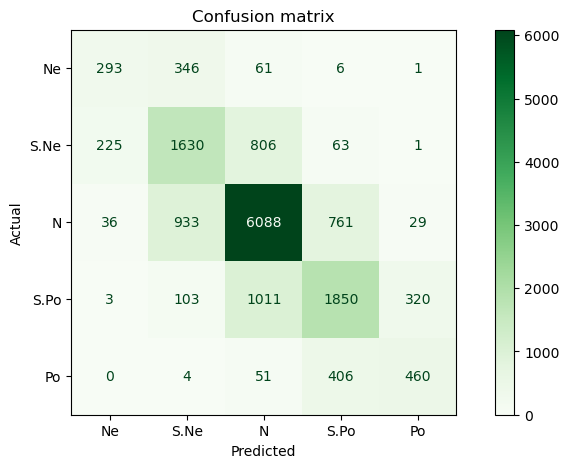

In [122]:
draw_cm(y_true, y_pred)

#### 🦭 v1.0.3 Handle class_weight problem

##### 🎊 Configuration

In [ ]:
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 31,
    "class_weight" : "balanced"
}

##### 🎬 Data cleaning, Vocabulary building

In [ ]:
############################################### DATA CLEANING
STOP_WORDS = set(stopwords.words("english"))

keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

# optional domain-specific words to REMOVE
# contextual_words = {"movie", "film"}

# final stopwords
STOP_WORDS = STOP_WORDS - keep_words


def cleaning(text):
    # lowercase
    text = text.lower()
    
    # remove parser's artifact
    text = re.sub(r"-lrb-|-rrb-", " ", text)
    
    # contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    
    # punctuation
    text = re.sub(r"[^a-z!? ]", " ", text)
    
    # split by <space>
    tokens = text.split()
    
    # stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS]
    
    # join
    text = " ".join(tokens)
    
    return text

# Apply clean for both train/val
clean_df["Phrase"] = lstm["Phrase"].apply(lambda text: cleaning(text))
clean_df = clean_df[clean_df["Phrase"] != ""]

X = clean_df["Phrase"]
y = clean_df["Sentiment"]
############################################### TRAIN/VAL SPLITING
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
############################################### BUILD VOCAB AND DATASEt/DATALOADER
# input the series of text
def build_vocab(texts : pd.Series, max_size=20000):
    counter = Counter()
    
    for text in texts:
        words = text.split()
        counter.update(words)
    
    most_common = counter.most_common(max_size)
    
    vocab = {word: i+2 for i, (word, _) in enumerate(most_common)}
    
    # vocabulary index for <PAD> and <UNK>
    # for padding the sentence when len(seq) < seq_size
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    
    return vocab

vocab = build_vocab(X_train)

# Map sentence to sequence of ID
def encode(text : str, vocab):
    # if word is unknown then <UNK>
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

# Encode sentence -> Sequence of IDs
X_train_seq = [encode(text, vocab) for text in X_train]

# Use the vocabulary learned from the train set
X_val_seq = [encode(text, vocab) for text in X_val]

# Padding
MAX_LEN = config["max_seq_len"]

def pad(seq : list[int], max_len=MAX_LEN):
    # less than max_len -> pad pad
    if len(seq) < max_len:
        # 0 is the index of <PAD>
        seq = seq + [0]*(max_len - len(seq))
    else:
    # greater than max_len -> get up to max_len
        seq = seq[:max_len]
        
    # return the seq of index of MAX_LEN
    return seq

# (train_size, MAX_LEN)
X_train_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_train_seq] )

# (val_size, MAX_LEN)
X_val_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_val_seq] )

y_train_series = y_train
y_val_series = y_val

y_train = torch.tensor(y_train.values)
y_val = torch.tensor(y_val.values)

In [ ]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        # tensor X and y
        # X shape (train_size, seq_size)
        # ID ID ID ID
        # ID ID ID ID
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
class M1(nn.Module):
    def __init__(
            self, 
            vocab_size, 
            embed_dim, 
            hidden_dim, 
            num_classes
        ):
        super().__init__()
        
        # input is a tensor of padding [ID, ID, ID, ID, ID]
        
        # embedding layer
        # a simple look up for embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        
        # lstm layer
        # each time step, each token -> embedding_dim
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            # hidden_dim,
            batch_first=True,
            num_layers=1,
            # device=device
        )
        
        # self.dropout = nn.Dropout(0.3)
        
        # dense layer
        self.fc = nn.Linear(
            in_features=hidden_dim, 
            out_features=num_classes
        )
    
    def forward(self, x):
        # x: (batch_size, seq_len)

        embedded = self.embedding(x)
        # (batch_size, seq_len, embed_dim)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Take the last hidden state
        last_hidden = hidden[-1]
        # (batch_size, hidden_dim)

        # out = self.dropout(last_hidden)
        out = self.fc(last_hidden)

        return out

In [ ]:
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v1.0.3",
    config=config,
)

# train/val dataset
train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)

# Load the tensor from the dataset X_train, y_train
# (batch_size, seq_size)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Create the model
model = M1(
    vocab_size=config["vocab_size"],
    embed_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    num_classes=config["num_classes"],
)

# Move model to device
model = model.to(device)

# Loss function
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_series),
    y=y_train_series
)

# Move class_weight to device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=config["learning_rate"]
    )

train_model_v1(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=config["epochs"]
)

🤩 Epoch 1 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.6095
🍖 ######### Val Loss: 1.6093
🍖 ######### Val Acc: 0.2121
🍖 ######### Val F1 Macro: 0.0704
🍖 ######### Val F1 Weighted: 0.0744
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 2 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.6103
🍖 ######### Val Loss: 1.6082
🍖 ######### Val Acc: 0.4302
🍖 ######### Val F1 Macro: 0.1802
🍖 ######### Val F1 Weighted: 0.3662
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 3 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.5540
🍖 ######### Val Loss: 1.4046
🍖 ######### Val Acc: 0.4955
🍖 ######### Val F1 Macro: 0.3097
🍖 ######### Val F1 Weighted: 0.4640
✅✅✅✅✅✅ Validation improved — model saved

🤩 Epoch 4 started
💿 ##### Train starts
💿 ##### Evaluation starts
🍖 ######### Train Loss: 1.2700
🍖 ######### Val Loss: 1.1733
🍖 ######### Val Acc: 0.4777
🍖 ######### Val F1 Macro: 0.4346
🍖 ######### Val F1 Wei

In [ ]:
y_true, y_pred = evaluate_model(model, val_loader)

Accuracy: 0.5704
F1 Macro: 0.5182
F1 Weighted: 0.5838

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.70      0.44       707
           1       0.44      0.50      0.47      2725
           2       0.81      0.60      0.69      7847
           3       0.48      0.45      0.47      3287
           4       0.38      0.79      0.52       921

    accuracy                           0.57     15487
   macro avg       0.49      0.61      0.52     15487
weighted avg       0.63      0.57      0.58     15487



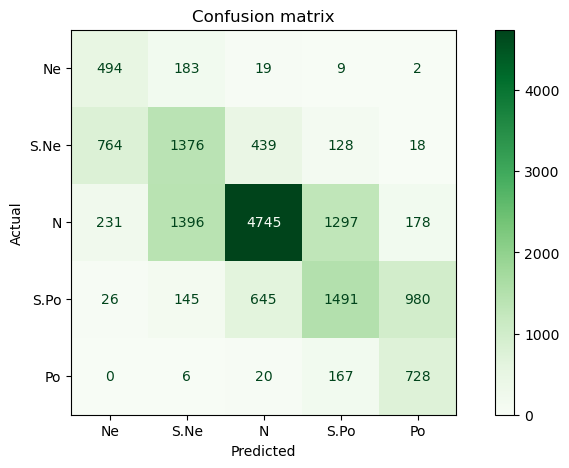

In [ ]:
draw_cm(y_true, y_pred)

#### 🎹 v1.0.4 Tune class_weight more correctly to find a sweetpoint

##### 🎊 Configuration

##### 🎬 Data cleaning, Vocabulary building

In [18]:
############################################### DATA CLEANING
STOP_WORDS = set(stopwords.words("english"))

keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

# optional domain-specific words to REMOVE
# contextual_words = {"movie", "film"}

# final stopwords
STOP_WORDS = STOP_WORDS - keep_words


def cleaning(text):
    # lowercase
    text = text.lower()
    
    # remove parser's artifact
    text = re.sub(r"-lrb-|-rrb-", " ", text)
    
    # contractions
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    
    # punctuation
    text = re.sub(r"[^a-z!? ]", " ", text)
    
    # split by <space>
    tokens = text.split()
    
    # stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS]
    
    # join
    text = " ".join(tokens)
    
    return text

# Apply clean for both train/val
clean_df = lstm.copy()
clean_df["Phrase"] = lstm["Phrase"].apply(lambda text: cleaning(text))
clean_df = clean_df[clean_df["Phrase"] != ""]

X = clean_df["Phrase"]
y = clean_df["Sentiment"]
############################################### TRAIN/VAL SPLITING
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
############################################### BUILD VOCAB AND DATASEt/DATALOADER
# input the series of text
def build_vocab(texts : pd.Series, max_size=20000):
    counter = Counter()
    
    for text in texts:
        words = text.split()
        counter.update(words)
    
    most_common = counter.most_common(max_size)
    
    vocab = {word: i+2 for i, (word, _) in enumerate(most_common)}
    
    # vocabulary index for <PAD> and <UNK>
    # for padding the sentence when len(seq) < seq_size
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    
    return vocab

vocab = build_vocab(X_train)

# Map sentence to sequence of ID
def encode(text : str, vocab):
    # if word is unknown then <UNK>
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

# Encode sentence -> Sequence of IDs
X_train_seq = [encode(text, vocab) for text in X_train]

# Use the vocabulary learned from the train set
X_val_seq = [encode(text, vocab) for text in X_val]

# Padding
MAX_LEN = 31

def pad(seq : list[int], max_len=MAX_LEN):
    # less than max_len -> pad pad
    if len(seq) < max_len:
        # 0 is the index of <PAD>
        seq = seq + [0]*(max_len - len(seq))
    else:
    # greater than max_len -> get up to max_len
        seq = seq[:max_len]
        
    # return the seq of index of MAX_LEN
    return seq

# (train_size, MAX_LEN)
X_train_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_train_seq] )

# (val_size, MAX_LEN)
X_val_pad = torch.tensor( [pad(seq, MAX_LEN) for seq in X_val_seq] )

y_train_series = y_train
y_val_series = y_val

y_train = torch.tensor(y_train.values)
y_val = torch.tensor(y_val.values)

In [19]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        # tensor X and y
        # X shape (train_size, seq_size)
        # ID ID ID ID
        # ID ID ID ID
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [20]:
class M1(nn.Module):
    def __init__(
            self, 
            vocab_size, 
            embed_dim, 
            hidden_dim, 
            num_classes
        ):
        super().__init__()
        
        # input is a tensor of padding [ID, ID, ID, ID, ID]
        
        # embedding layer
        # a simple look up for embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        
        # lstm layer
        # each time step, each token -> embedding_dim
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            # hidden_dim,
            batch_first=True,
            num_layers=1,
            # device=device
        )
        
        # self.dropout = nn.Dropout(0.3)
        
        # dense layer
        self.fc = nn.Linear(
            in_features=hidden_dim, 
            out_features=num_classes
        )
    
    def forward(self, x):
        # x: (batch_size, seq_len)

        embedded = self.embedding(x)
        # (batch_size, seq_len, embed_dim)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Take the last hidden state
        last_hidden = hidden[-1]
        # (batch_size, hidden_dim)

        # out = self.dropout(last_hidden)
        out = self.fc(last_hidden)

        return out

##### 🔗 To get the possible class_weight based on alpha

In [21]:
def get_class_weights(y_train, alpha):
    
    base_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    
    base_weights = base_weights / base_weights.mean()
    
    scaled_weights = base_weights ** alpha
    
    return torch.tensor(scaled_weights, dtype=torch.float).to(device)

##### 🗡️ Simple evaluation helper

In [14]:
def evaluate(model, val_loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            pred = outputs.argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    f1_macro = f1_score(labels, preds, average="macro")
    return f1_macro, preds, labels

In [133]:
import copy

##### 🇬🇭 Alpha loop to find the most possible alpha

In [ ]:
alphas = [0.0, 0.3, 0.5, 0.6, 0.7, 0.8, 1.0]
macro_f1 = []

best_alpha = None
best_f1 = -1
best_state = None

version = 4

for alpha in alphas:
    config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 31,
    "class_weight" : True,
    "alpha" : alpha,
}
    
    wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name=f"lstm_v1.0.{version}",
    config=config,)
    
    
    print(f"\n🔥 Training with alpha = {alpha}")
    
    # train/val dataset
    train_dataset = TextDataset(X_train_pad, y_train)
    val_dataset = TextDataset(X_val_pad, y_val)

    # Load the tensor from the dataset X_train, y_train
    # (batch_size, seq_size)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64)

    model = M1(
        vocab_size=config["vocab_size"],
        embed_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_classes=config["num_classes"],
    ).to(device)

    class_weights = get_class_weights(y_train_series, alpha)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    train_model_v1(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=config["epochs"]
    )

    f1, _, _ = evaluate(model, val_loader)

    print(f"Alpha: {alpha:.4f} --- Macro F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
        best_state = copy.deepcopy(model.state_dict())
        
    version += 1
    
    macro_f1.append(f1)

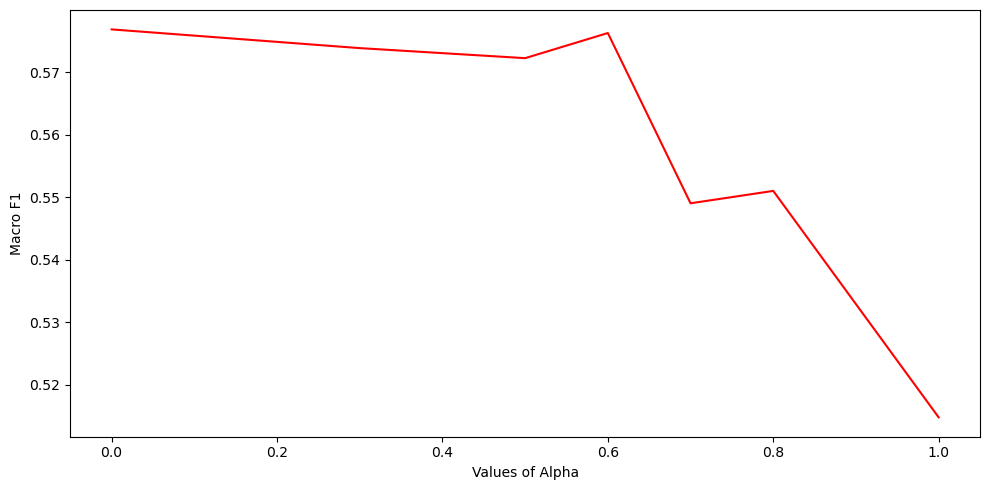

In [148]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(x=alphas, y=macro_f1, ax=ax, color="red")
ax.set_xlabel("Values of Alpha")
ax.set_ylabel("Macro F1")

plt.tight_layout()
plt.show()

##### 🕶️ Reduce range

In [ ]:
alphas = np.linspace(start=0.0, stop=0.2, num=7)
macro_f1 = []

best_alpha = None
best_f1 = -1
best_state = None

version = 11

for alpha in alphas:
    config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 31,
    "class_weight" : True,
    "alpha" : alpha,
}
    
    wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name=f"lstm_v1.0.{version}",
    config=config,)
    
    
    print(f"\n🔥 Training with alpha = {alpha}")

    model = M1(
        vocab_size=config["vocab_size"],
        embed_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_classes=config["num_classes"],
    ).to(device)

    class_weights = get_class_weights(y_train_series, alpha)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    train_model_v1(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=config["epochs"]
    )

    f1, _, _ = evaluate(model, val_loader)

    print(f"Alpha: {alpha:.4f} --- Macro F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
        best_state = copy.deepcopy(model.state_dict())
        
    version += 1
    
    macro_f1.append(f1)

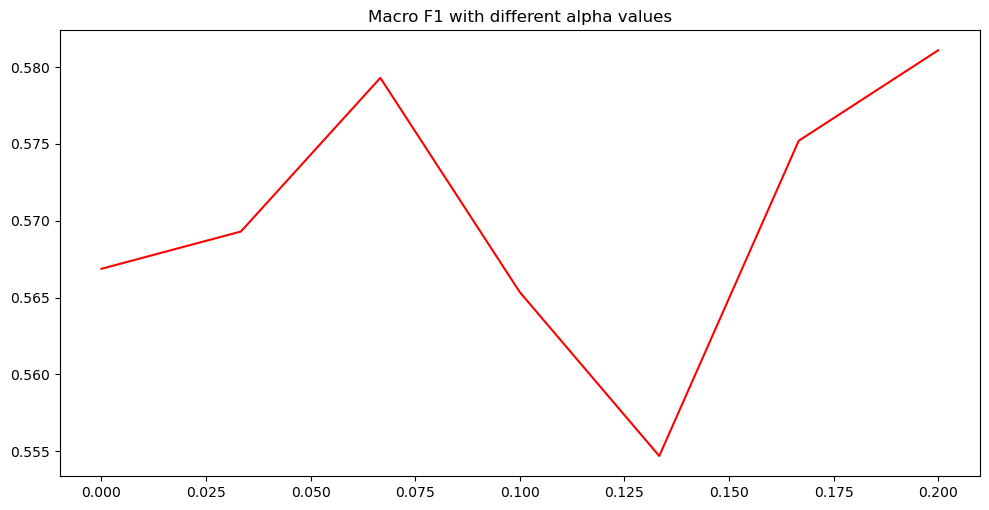

In [175]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=alphas, y=np.array(macro_f1), color="red")

plt.tight_layout()
plt.title("Macro F1 with different alpha values")
plt.show()

##### 🕶️ Reduce range

In [ ]:
alphas = np.linspace(start=0.050, stop=0.075, num=10)
macro_f1 = []

best_alpha = None
best_f1 = -1
best_state = None

version = 18

for alpha in alphas:
    config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "vocab_size" : len(vocab),
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes",
    "max_seq_len" : 31,
    "class_weight" : True,
    "alpha" : alpha,
}
    
    wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name=f"lstm_v1.0.{version}",
    config=config,)
    
    
    print(f"\n🔥 Training with alpha = {alpha}")
    
    # train/val dataset
    train_dataset = TextDataset(X_train_pad, y_train)
    val_dataset = TextDataset(X_val_pad, y_val)

    # Load the tensor from the dataset X_train, y_train
    # (batch_size, seq_size)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64)

    model = M1(
        vocab_size=config["vocab_size"],
        embed_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_classes=config["num_classes"],
    ).to(device)

    class_weights = get_class_weights(y_train_series, alpha)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    train_model_v1(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=config["epochs"]
    )

    f1, _, _ = evaluate(model, val_loader)

    print(f"Alpha: {alpha:.4f} --- Macro F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha
        best_state = copy.deepcopy(model.state_dict())
        
    version += 1
    
    macro_f1.append(f1)

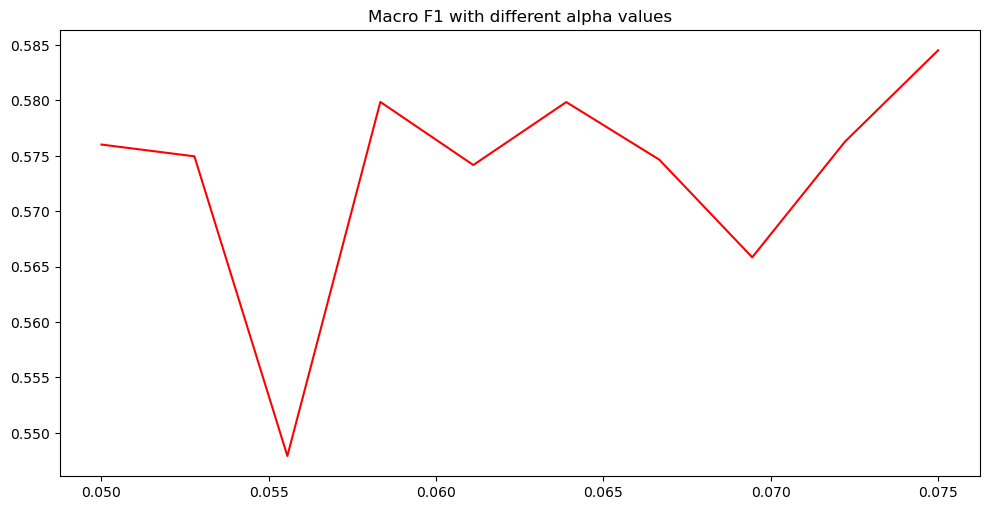

In [25]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=alphas, y=np.array(macro_f1), color="red")

plt.tight_layout()
plt.title("Macro F1 with different alpha values")
plt.show()